<a href="https://colab.research.google.com/github/ArlethSosa/Space-Y/blob/main/Space_Y_Parte_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Space Y**

## Parte 5. Analsis predictivo

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

In [2]:
import pandas as pd

from google.colab import drive
drive.mount('/content/drive')
#Obtener datos de la parte dos

url="/content/drive/MyDrive/dataset_part_2.csv"
df=pd.read_csv(url)


Mounted at /content/drive


In [3]:
url2="/content/drive/MyDrive/dataset_machine_learning.csv"
#obtener datos que s eprepararon para machine learning
X=pd.read_csv(url2)
X.head()
data =X
data.head()

,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1,6123.547647,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2,525.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
2,3,677.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
3,4,500.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
4,5,3170.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False


In [4]:
#Se convierte la columna Class a NumPy para usarla en  modelos.
Y = df['Class'].to_numpy()
print(Y)


[0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 1 0 0 1 1 1 1 1 0 1 1 0 1 1 0 1 1 1 0 1 1
 1 1 1 1 1 1 1 1 0 0 0 1 1 0 0 1 1 1 1 1 1 1 0 0 1 1 1 1 1 1 0 1 1 1 1 0 1
 0 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1]


In [5]:
#Estandariza los datos de X
transform = preprocessing.StandardScaler()
X = transform.fit_transform(X)

In [6]:
X_train, X_test, Y_train, Y_test=train_test_split(X,Y, test_size=0.2, random_state=2) #SEparaamos los datos para test y entrenamiento

In [7]:
Y_test.shape #18 filas para test


(18,)

In [8]:
X_test

array([[ 0.13472338, -1.22691278, -0.65391284, ..., -0.21566555,
        -0.18569534, -0.10599979],
       [ 1.25100281,  2.01380177,  1.83279796, ..., -0.21566555,
        -0.18569534, -0.10599979],
       [ 1.40497238, -0.47676705, -0.65391284, ..., -0.21566555,
         5.38516481, -0.10599979],
       ...,
       [-0.6351245 , -0.17500871,  0.17499076, ..., -0.21566555,
        -0.18569534, -0.10599979],
       [-1.2894952 , -0.79233827, -0.65391284, ..., -0.21566555,
        -0.18569534, -0.10599979],
       [-0.82758647, -0.32376282, -0.65391284, ..., -0.21566555,
        -0.18569534, -0.10599979]])

### 1.Regresión logistica
Se crea un objeto de regresión logística y luego se crea un objeto `GridSearchCV` llamado `logreg_cv` con `cv = 5`. Se ajusta el objeto para encontrar los mejores parámetros del diccionario `parameters`.


In [9]:
#Parametros para probar el modelo
parameters ={'C':[0.01,0.1,1],
             'penalty':['l2'],
             'solver':['lbfgs']} #Penalización para evitar overfitting

In [10]:

lr=LogisticRegression() #Regresion logistica
# GridSearchCV
logreg_cv = GridSearchCV(lr, parameters, cv=5) #Corss validation: divide datos en 5 partes, entonces entrena 5 veces y evalua promedio

# entrenamiento de modelo
logreg_cv.fit(X_train, Y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(),
             param_grid={'C': [0.01, 0.1, 1], 'penalty': ['l2'],
                         'solver': ['lbfgs']})

In [11]:
print("Mejores parametros ",logreg_cv.best_params_)
print("accuracy :",logreg_cv.best_score_)

Mejores parametros  {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}
accuracy : 0.8476190476190476


Para el modelo de regresión logistica con cv=5, los mejores parametros son c=0.1, penalty=l2, solver=lbfgs con un accuracy de 0.847

In [12]:
#Calcular exactitud de datos de test
logreg_cv.score(X_test, Y_test)

0.8333333333333334

El accuracy del modelo de regresión logistica es de 0.83 con los datos de test.

In [13]:
#Función para imprimir matriz de confusión
def plot_confusion_matrix(y,y_predict):
    "this function plots the confusion matrix"
    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(y, y_predict)
    ax= plt.subplot()
    sns.heatmap(cm, annot=True, ax = ax);
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix');
    ax.xaxis.set_ticklabels(['did not land', 'land']); ax.yaxis.set_ticklabels(['did not land', 'landed'])
    plt.show()

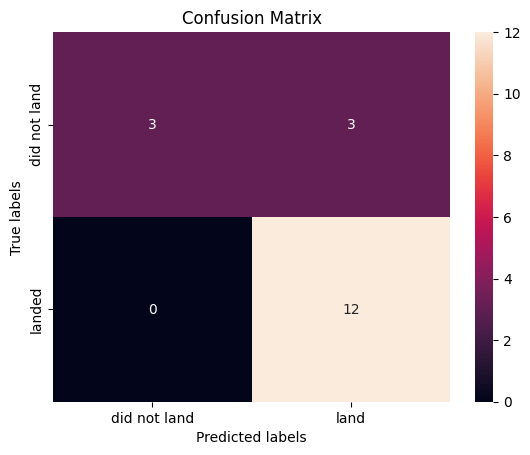

In [14]:
yhat=logreg_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

In [15]:
fp_indices = np.where((yhat == 1) & (Y_test == 0))
fp_indices

(array([ 8, 11, 16]),)

Podemos observar que el problema de la regresion logistica es que esta arrojando falsos positivos, se etiquetaron 3 datos como aterrizaje exitoso cuando en realidad no se obtuvo un aterrizaje exitoso.

### 2. Support vector machine




In [16]:
#Asignamos los parametros para probar cual se ajusta mejor
parametros = {'kernel':('linear', 'rbf','poly','rbf', 'sigmoid'),
              'C': np.logspace(-3, 3, 5),
              'gamma':np.logspace(-3, 3, 5)}

In [17]:
#Creación del modelo
svm_modelo = SVC()
svm_cv = GridSearchCV(svm_modelo, parametros, cv=5)

In [18]:
svm_cv.fit(X_train, Y_train)

GridSearchCV(cv=5, estimator=SVC(),
             param_grid={'C': array([1.00000000e-03, 3.16227766e-02, 1.00000000e+00, 3.16227766e+01,
       1.00000000e+03]),
                         'gamma': array([1.00000000e-03, 3.16227766e-02, 1.00000000e+00, 3.16227766e+01,
       1.00000000e+03]),
                         'kernel': ('linear', 'rbf', 'poly', 'rbf', 'sigmoid')})

In [19]:
print("Mejores parametros ",svm_cv.best_params_)
print("Accuracy :",svm_cv.best_score_)

Mejores parametros  {'C': np.float64(1.0), 'gamma': np.float64(0.03162277660168379), 'kernel': 'sigmoid'}
Accuracy : 0.82


Los mejores parametros para este modelo son c=1.0, gamma=0.03162277660168379, kernel=sigmoid con accuracy de 0.82

Calcular accuracy con los datos de test

In [20]:
svm_cv.score(X_test, Y_test)

0.8333333333333334

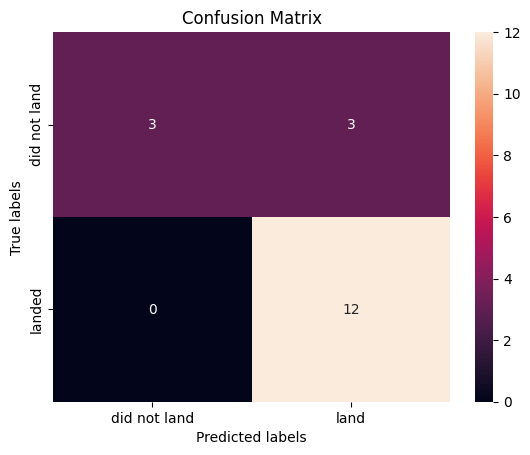

In [21]:
#Graficar tabla de confusión
yhat=svm_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

In [22]:
fp_indices = np.where((yhat == 1) & (Y_test == 0))
fp_indices

(array([ 8, 11, 16]),)

Con el modelo support vector machine tambien se pueden observar 3 falsos positivos como en regresión logistica y ambos mantitnen un accuracy igual de 0.83

In [23]:
from sklearn.metrics import classification_report
print(classification_report(Y_test, yhat))

              precision    recall  f1-score   support

           0       1.00      0.50      0.67         6
           1       0.80      1.00      0.89        12

    accuracy                           0.83        18
   macro avg       0.90      0.75      0.78        18
weighted avg       0.87      0.83      0.81        18



### 3. Arbol de desición

In [46]:
parametros2 = {'criterion': ['gini', 'entropy'],
     'splitter': ['best', 'random'],
     'max_depth': [2*n for n in range(1,10)],
     'max_features': ['sqrt'],
     'min_samples_leaf': [1, 2, 4],
     'min_samples_split': [2, 5, 10]}

tree = DecisionTreeClassifier(random_state=42)
tree_cv = GridSearchCV (tree,parametros2, cv=5)

In [47]:
tree_cv.fit(X_train, Y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [2, 4, 6, 8, 10, 12, 14, 16, 18],
                         'max_features': ['sqrt'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'splitter': ['best', 'random']})

In [48]:
print("Mejores parametros ",tree_cv.best_params_)
print("Exactitud :",tree_cv.best_score_)

Mejores parametros  {'criterion': 'entropy', 'max_depth': 6, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'splitter': 'random'}
Exactitud : 0.8485714285714285


In [49]:
tree_cv.score(X_test, Y_test)

0.8333333333333334

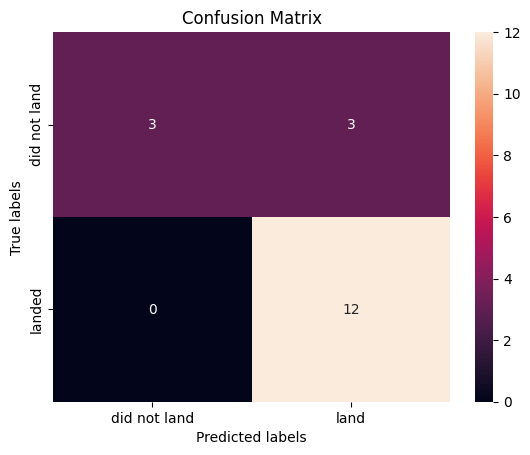

In [50]:
#Matriz de confusion
yhat = tree_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

In [51]:
from sklearn.metrics import classification_report
print(classification_report(Y_test, yhat))

              precision    recall  f1-score   support

           0       1.00      0.50      0.67         6
           1       0.80      1.00      0.89        12

    accuracy                           0.83        18
   macro avg       0.90      0.75      0.78        18
weighted avg       0.87      0.83      0.81        18



In [52]:
fp_indices = np.where((yhat == 1) & (Y_test == 0))
fp_indices

(array([ 8, 11, 16]),)

Con el modelo de arbol de desición se tiene 3 falsos positivos y el accuracy es de 0.833

### 4. K nearest neihbors

In [31]:
parameters = {'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
              'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
              'p': [1,2]}

KNN = KNeighborsClassifier()
knn_cv=GridSearchCV(KNN, parameters, cv=10)

In [32]:
knn_cv.fit(X_train, Y_train)

GridSearchCV(cv=10, estimator=KNeighborsClassifier(),
             param_grid={'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
                         'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
                         'p': [1, 2]})

In [33]:
print("Mejores parametros",knn_cv.best_params_)
print("accuracy :",knn_cv.best_score_)

Mejores parametros {'algorithm': 'auto', 'n_neighbors': 3, 'p': 1}
accuracy : 0.8214285714285714


In [34]:
knn_cv.score(X_test, Y_test)

0.8333333333333334

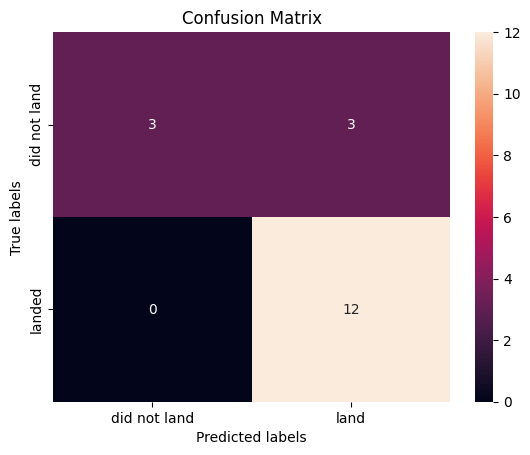

In [35]:
yhat = knn_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

In [36]:
from sklearn.metrics import classification_report
print(classification_report(Y_test, yhat))

              precision    recall  f1-score   support

           0       1.00      0.50      0.67         6
           1       0.80      1.00      0.89        12

    accuracy                           0.83        18
   macro avg       0.90      0.75      0.78        18
weighted avg       0.87      0.83      0.81        18



In [37]:
fp_indices = np.where((yhat == 1) & (Y_test == 0))
fp_indices

(array([ 8, 11, 16]),)

### 5. Análisis

Se evaluaron múltiples modelos de clasificación (KNN, Decision Tree y Regresión Logística), obteniendo resultados idénticos en todas las métricas. Este comportamiento sugiere que los datos presentan patrones claramente definidos para la clase 1, pero ambigüedad en la clase 0, lo que provoca errores consistentes en las mismas observaciones. Por lo tanto, la mejora del modelo requeriría un análisis más profundo de las características o una mejor representación de los datos, en lugar de un cambio de algoritmo.

Identificar los 3 errores de falsos positivos

In [38]:
#Para todoos los modelos los fasos positivos son los mismos
fp_indices

(array([ 8, 11, 16]),)

los valores lanzamientos no tuvieron un aterrizaje exitoso

In [39]:

Y_test[fp_indices]

array([0, 0, 0])

sin embargo los modelos lo clasifican como exitoso

In [40]:
yhat = tree_cv.predict(X_test[fp_indices])

yhat2=logreg_cv.predict(X_test[fp_indices])

print(yhat, yhat2)

[1 1 1] [1 1 1]


Los modelos etiquetan los tres caoss como clase 1 con una probabilida de mas del 70%, aunque estos son 0. Esto puede ser por que tienen caracteristicas muy similares a los del caso 1, por ejemplo que son numero de lanzamiento altos y el modelo los toma como clase 1.

In [41]:
tree_cv.predict_proba(X_test[[8, 11, 16]])

array([[0.20689655, 0.79310345],
       [0.20689655, 0.79310345],
       [0.20689655, 0.79310345]])

In [42]:
logreg_cv.predict_proba(X_test[[8, 11, 16]])

array([[0.08893824, 0.91106176],
       [0.27529924, 0.72470076],
       [0.27607759, 0.72392241]])

In [43]:
X_fp_original = transform.inverse_transform(X_test[[8,11,16]])
X_fp_original

array([[7.500e+01, 1.560e+04, 4.000e+00, 1.000e+00, 1.000e+00, 1.000e+00,
        5.000e+00, 3.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        1.000e+00, 1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        1.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+00, 0.000e+00, 1.000e+00, 0.000e+00,
        0.000e+00, 0.000e+00, 0.000e+0

In [44]:
falsos_positivos_df = pd.DataFrame(X_fp_original)
falsos_positivos_df

,0,1,2,3,4,5,6,7,8,9,...,71,72,73,74,75,76,77,78,79,80
0,75.0,15600.0,4.0,1.0,1.0,1.0,5.0,3.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
1,14.0,1898.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,12.0,2395.0,1.0,1.0,0.0,1.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [45]:
df.iloc[[74,13,11]]

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
74,75,2020-02-17,Falcon 9,15600.0,VLEO,CCSFS SLC 40,False ASDS,4,True,True,True,5e9e3032383ecb6bb234e7ca,5.0,3,B1056,-80.577366,28.561857,0
13,14,2015-04-14,Falcon 9,1898.0,ISS,CCSFS SLC 40,False ASDS,1,True,False,True,5e9e3032383ecb761634e7cb,1.0,0,B1015,-80.577366,28.561857,0
11,12,2015-01-10,Falcon 9,2395.0,ISS,CCSFS SLC 40,False ASDS,1,True,False,True,5e9e3032383ecb761634e7cb,1.0,0,B1012,-80.577366,28.561857,0


Como se muestras en el df aneterior se muestran los 3 casos de falsos positivos, las caracteristicas que estos tienen en comun es "LaunchSite" = CCSFS SLC 40 y "Outcome" = False ASDS